In [45]:
import json
import os
import re
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcol
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import osmnx as ox
import pandas as pd
import requests
import seaborn as sns
import sqlalchemy

In [46]:
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}@{os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}/{os.environ['POSTGRES_DB']}",
)

In [47]:
data_path = Path(os.environ["DATA_PATH"])
generated_path = data_path / "generated"
scripts_path = Path("./scripts")
figure_path = Path("./figures")

In [48]:
df_orig = pd.read_parquet(generated_path / "registro.parquet").assign(
    fraccionamiento=lambda df: df["fraccionamiento"].where(
        lambda x: ~x.str.startswith("privadas condesa"),
        lambda x: x + " (" + df["privada"].str.casefold() + ")",
    ),
)

In [49]:
def fix_condesa_col(x: str) -> str:
    if not x.startswith("privadas condesa"):
        return x

    res = re.search(r"privadas condesa seccion (.+)", x)
    if res is None:
        err = f"Unexpected format for {x}"
        raise ValueError(err)
    name = res.group(1)
    return f"privadas condesa ({name})"


df_col = (
    gpd.read_file(data_path / "initial" / "lim_cols_cp")
    .to_crs("EPSG:6372")
    .dropna(subset=["COLONIAS"])
    .assign(
        COLONIAS=lambda df: (
            df["COLONIAS"]
            .str.casefold()
            .str.replace(r"fracc\.?", "", regex=True)
            .str.replace("fraccionamiento", "")
            .str.strip()
            .replace(
                {
                    "quinta granada": pd.NA,
                    "valle de puebla": pd.NA,  # Replace with NA to fill with specific section
                    "la condesa": pd.NA,
                    "victoria residencial": pd.NA,
                },
            )
            .where(lambda x: ~x.isna(), df["Col_Secc"].str.casefold())
            .replace(
                {
                    "des. hab. privada campestre": "privadas campestre",
                    "camino del sol": "caminos del sol",
                    "balbuena condominios": "colonia balbuena",
                    "balbuena": "colonia balbuena",
                    "corceles": "corceles residencial",
                    "la condesa seccion fontalba": "fontalba residencial",
                    "valle de puebla quinta etapa": "valle de puebla 5ta secc.",
                    "quinta granada primera etapa": "quinta granada",
                    "quinta granada tercera etapa": "quinta granada 3",
                    "desarrollo habitacional residencial natura": "residencial natura",
                },
            )
            .str.replace("la condesa", "privadas condesa")
            .str.replace("seccio0n", "seccion")
            .str.replace("leganes", "leganés")
            .apply(fix_condesa_col)
            .replace(
                {
                    "fracc. victoria residencial segunda seccion": "privadas condesa (victoria segunda seccion)",
                },
            )
        ),
    )[["COLONIAS", "geometry"]]
    .dissolve(by="COLONIAS")
)

# Stats

## Tree coverage

In [50]:
response = requests.post(
    f"https://{os.environ['LYRA_HOST']}/tree_coverage/geojson",
    json={
        "geojson": json.loads(
            df_col[["geometry"]].reset_index(names="cvegeo").to_json(),
        ),
    },
    headers={
        "P-Access-Token-Id": os.environ["PANGOLIN_ACCES_TOKEN_ID"],
        "P-Access-Token": os.environ["PANGOLIN_ACCESS_TOKEN"],
    },
    timeout=100,
)

df_col = df_col.assign(
    tree_coverage_m2=pd.Series(response.json()),
    tree_coverage_frac=lambda df: df["tree_coverage_m2"] / df["geometry"].area,
).drop(columns=["tree_coverage_m2"])

## Urbanized area

In [51]:
response = requests.post(
    f"https://{os.environ['LYRA_HOST']}/urbanized_area/geojson",
    json={
        "geojson": json.loads(
            df_col[["geometry"]].reset_index(names="cvegeo").to_json(),
        ),
    },
    headers={
        "P-Access-Token-Id": os.environ["PANGOLIN_ACCES_TOKEN_ID"],
        "P-Access-Token": os.environ["PANGOLIN_ACCESS_TOKEN"],
    },
    timeout=100,
)

df_col = df_col.assign(
    urbanized_area_m2=pd.Series(response.json()),
    urbanized_area_frac=lambda df: df["urbanized_area_m2"] / df["geometry"].area,
).drop(columns=["urbanized_area_m2"])

## Accessibility

### Jobs

In [52]:
df_park = (
    gpd.read_file(data_path / "initial" / "esp_pub", columns=["TIPO", "Sup_M2"])
    .query(
        "TIPO.isin(['JARDIN VECINAL', 'PARQUE DE BARRIO', 'JARDINES', 'JARDINES (VIVERO MPAL)', 'PARQUE URBANO'])",
    )
    .assign(
        geometry=lambda df: df["geometry"].force_2d().centroid,
        amenity="Parques recreativos",
    )
    .rename(columns={"Sup_M2": "area"})
    .drop(columns=["TIPO"])
    .to_crs("EPSG:6372")
)

In [53]:
group_patterns = [r"3[1-3]\d{4}"]

response = requests.post(
    f"https://{os.environ['LYRA_HOST']}/accessibility_jobs/geojson",
    json={
        "geojson": json.loads(
            df_col[["geometry"]].reset_index(names="cvegeo").to_json(),
        ),
        "group_patterns": group_patterns,
    },
    headers={
        "P-Access-Token-Id": os.environ["PANGOLIN_ACCES_TOKEN_ID"],
        "P-Access-Token": os.environ["PANGOLIN_ACCESS_TOKEN"],
    },
    timeout=100,
)

df_col = (
    df_col.drop(
        columns=["jobs"] + [f"jobs_{i}" for i in range(len(group_patterns))],
        errors="ignore",
    )
    .join(pd.DataFrame(response.json()).transpose())
    .rename(columns={"jobs_0": "jobs_manufacture"})
)

### Services

In [56]:
df_mesh = gpd.read_file(generated_path / "mesh_accessibility.gpkg")

In [57]:
accessibility = gpd.GeoDataFrame(
    df_col[["geometry"]]
    .to_crs("EPSG:6372")
    .sjoin(df_mesh[["geometry", "accessibility_score"]], how="left")
    .groupby("COLONIAS")
    .agg({"accessibility_score": "mean", "geometry": "first"}),
    crs=df_mesh.crs,
).rename(columns={"accessibility_score": "accessibility"})["accessibility"]

df_col = df_col.assign(accessibility=accessibility)

## Distance to city center

In [58]:
with engine.connect() as conn:
    city_center = gpd.read_postgis(
        """
        SELECT geometry FROM centroids_historical
        WHERE cve_met = '02.2.03'
        """,
        conn,
        geom_col="geometry",
    ).to_crs("EPSG:6372")

In [59]:
g = ox.graph_from_bbox(
    df_col.assign(geometry=lambda df: df["geometry"].buffer(5000))
    .to_crs("EPSG:4326")
    .total_bounds,
)
g = ox.add_edge_speeds(g)
g = ox.add_edge_travel_times(g)

In [60]:
cent = df_col.centroid.to_crs("EPSG:4326")
col_nodes = ox.nearest_nodes(g, cent.x, cent.y)

city_center_node = ox.nearest_nodes(
    g,
    city_center.to_crs("EPSG:4326")["geometry"].x,
    city_center.to_crs("EPSG:4326")["geometry"].y,
)[0]

In [61]:
shortest_paths = ox.shortest_path(
    g,
    col_nodes,
    [city_center_node] * len(col_nodes),
    weight="travel_time",
    cpus=8,
)
travel_times = [
    ox.routing.route_to_gdf(g, path, weight="travel_time")["travel_time"].sum()
    if path is not None
    else np.nan
    for path in shortest_paths
]
df_col = df_col.assign(travel_time_to_center=travel_times)

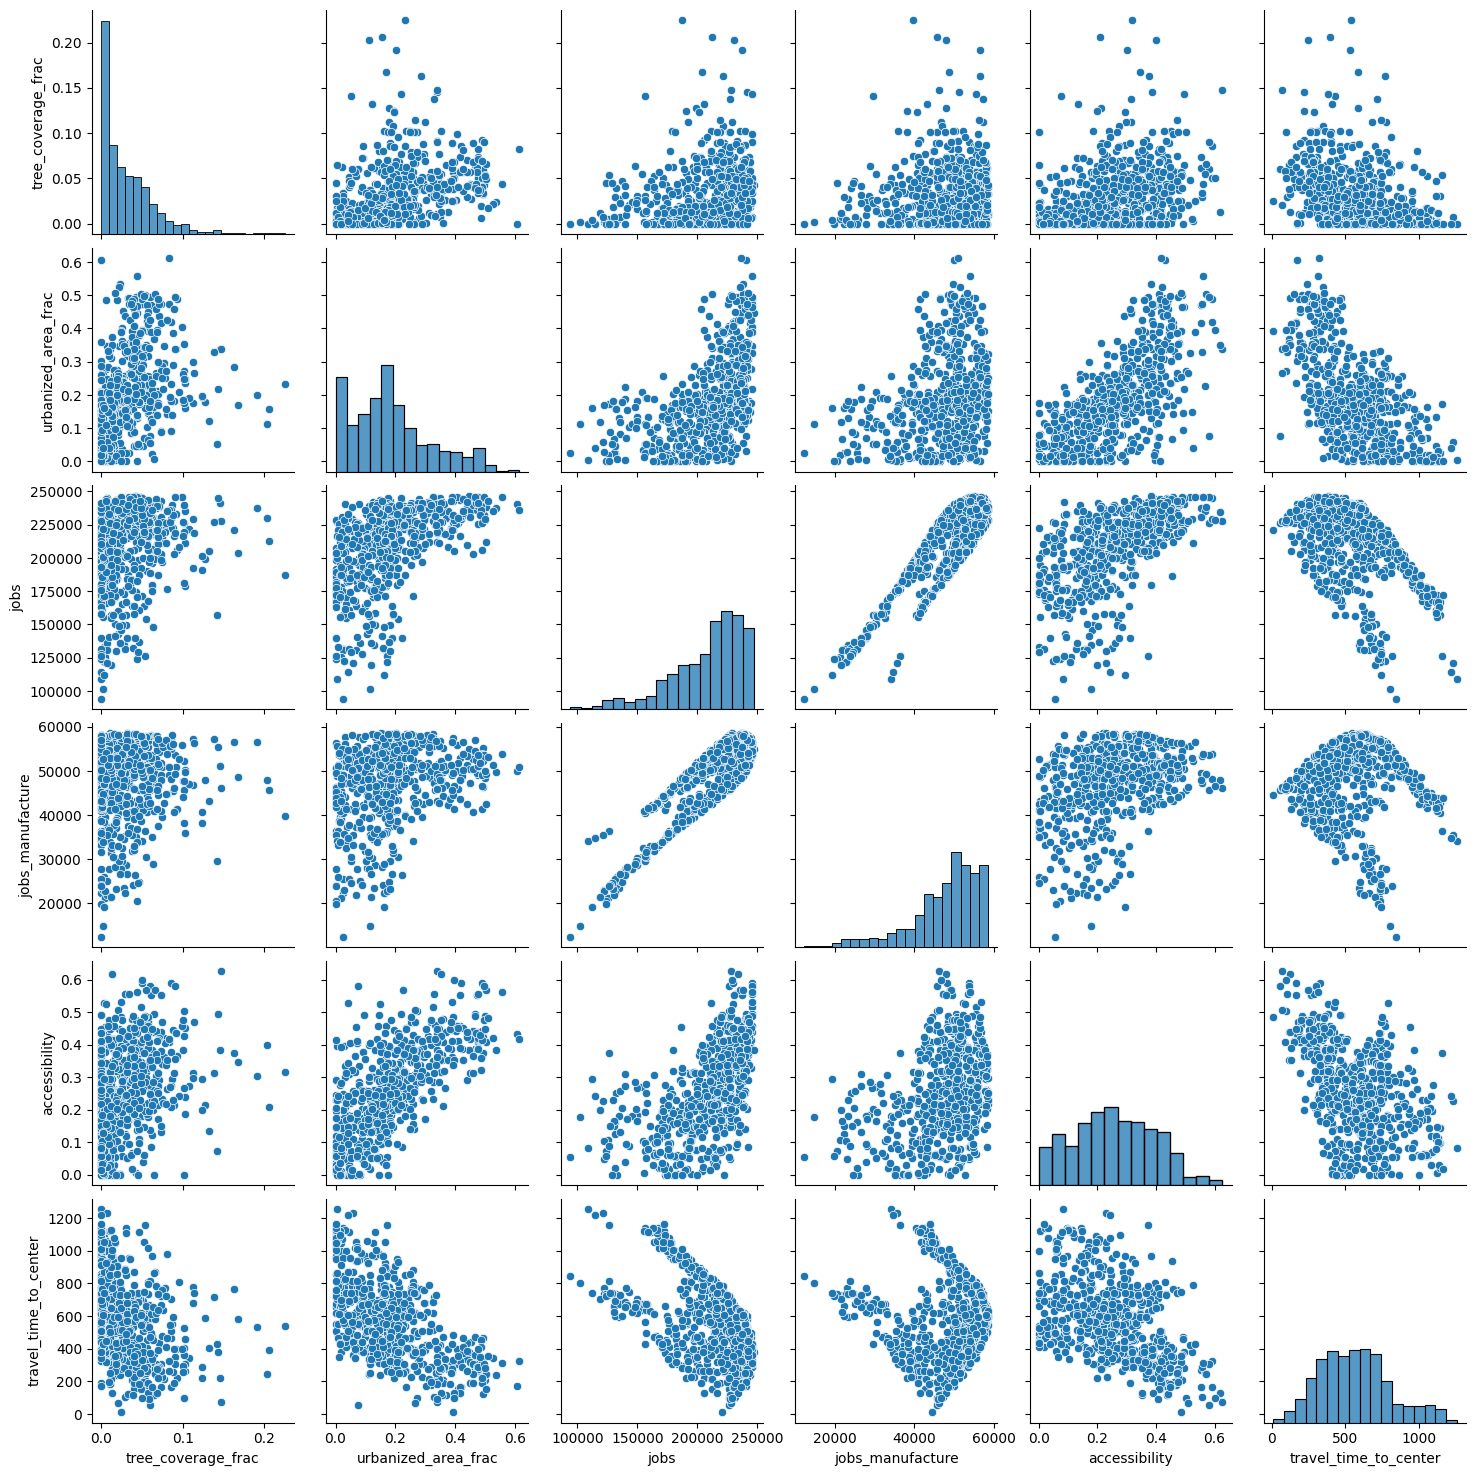

In [62]:
sns.pairplot(df_col.drop(columns=["geometry"]))

In [68]:
df_col.to_parquet("./cols.geoparquet")

In [74]:
merged

,fraccionamiento,fecha_operacion,valor_operacion,monto_credito,geometry,tree_coverage_frac,urbanized_area_frac,jobs,jobs_manufacture,accessibility,travel_time_to_center
0,la rioja seccion castilla,2021-02-11,600000.00,NaN,"POLYGON ((1238719.086 2346513.468, 1238731.499...",0.005556,0.147654,195386.822185,47079.409561,0.120852,687.384224
1,la rioja seccion castilla,2020-04-20,893688.06,NaN,"POLYGON ((1238719.086 2346513.468, 1238731.499...",0.005556,0.147654,195386.822185,47079.409561,0.120852,687.384224
2,valle del progreso,2024-12-30,680000.00,1293806.96,"POLYGON ((1217866.272 2341363.019, 1218124.252...",0.000000,0.088346,127424.635240,24271.392074,0.151123,739.536661
3,valle del progreso,2024-12-23,680000.00,1300408.02,"POLYGON ((1217866.272 2341363.019, 1218124.252...",0.000000,0.088346,127424.635240,24271.392074,0.151123,739.536661
4,valle del progreso,2024-12-23,680000.00,1234397.46,"POLYGON ((1217866.272 2341363.019, 1218124.252...",0.000000,0.088346,127424.635240,24271.392074,0.151123,739.536661
...,...,...,...,...,...,...,...,...,...,...,...
7128,parajes de puebla,2020-01-10,426000.00,425057.32,"MULTIPOLYGON (((1240422.839 2334785.61, 124062...",0.001291,0.031716,161912.636696,42281.558197,0.113119,1125.239429
7129,parajes de puebla,2020-01-10,426000.00,364726.17,"MULTIPOLYGON (((1240422.839 2334785.61, 124062...",0.001291,0.031716,161912.636696,42281.558197,0.113119,1125.239429
7130,privadas campestre,2020-01-10,920000.00,NaN,"POLYGON ((1232502.712 2338350.126, 1232136.202...",0.000000,0.021990,219639.503302,55048.569545,0.069705,656.870732
7131,angeles de puebla,2020-01-08,483000.00,447475.68,"POLYGON ((1239332.165 2335965.554, 1239296.874...",0.017377,0.126476,170296.140736,44032.751472,0.187450,1045.492492


In [75]:
merged = df_orig[
    ["fraccionamiento", "fecha_operacion", "valor_operacion", "monto_credito"]
].merge(
    df_col.reset_index(names="fraccionamiento").drop(columns=["geometry"]),
    on="fraccionamiento",
    how="inner",
)
merged.to_parquet("./merged.parquet")

## Inmobiliaria

In [ ]:
exe_frac = df_orig.loc[lambda df: df["mercado_exe"], "fraccionamiento"].unique()
df_col.loc[lambda df: df.index.isin(exe_frac), "is_exe"] = True
df_col = df_col.assign(is_exe=lambda df: df["is_exe"].fillna(False))

C:\Users\lain\AppData\Local\Temp\ipykernel_15680\474021561.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_col = df_col.assign(is_exe=lambda df: df["is_exe"].fillna(False))


# Plot

In [ ]:
df_merge = df_orig.merge(
    df_col.reset_index(names="fraccionamiento"),
    on="fraccionamiento",
    how="left",
).pipe(gpd.GeoDataFrame, geometry="geometry", crs=df_col.crs)

<Axes: ylabel='privada'>

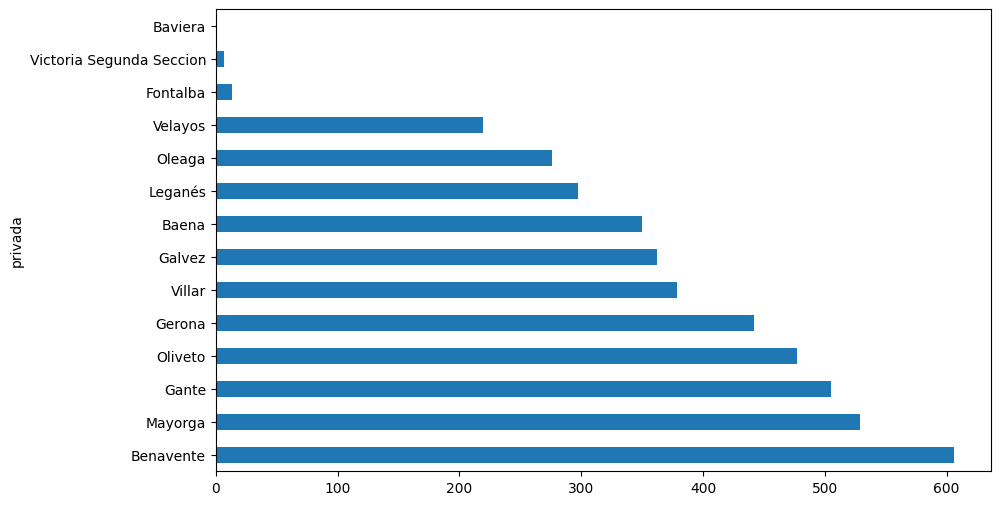

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
df_merge["privada"].str.title().value_counts().plot.barh(ax=ax)

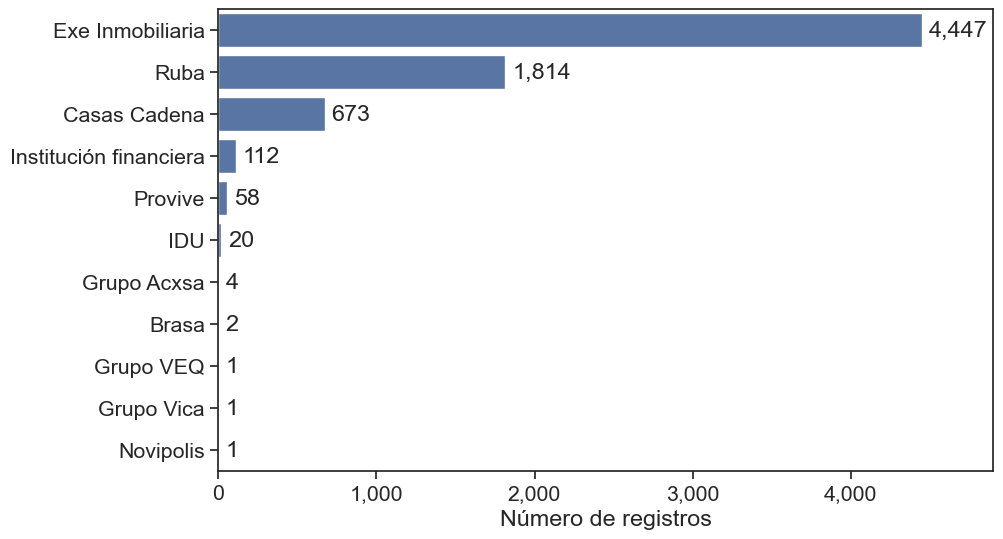

In [ ]:
sns.set_theme(style="ticks", font_scale=1.4)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_orig["inmobiliaria"].value_counts(), ax=ax, orient="h")
ax.set_xlabel("Número de registros")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=5)
ax.set_xlim(0, 4900)
fig.savefig(figure_path / "inmobiliarias.jpg", bbox_inches="tight", dpi=300)

In [ ]:
df_col

,geometry,tree_coverage_frac,urbanized_area_frac,jobs,jobs_0,accessibility,travel_time_to_center,is_exe
COLONIAS,,,,,,,,
18 de marzo,"POLYGON ((1233389.196 2343271.04, 1233342.023 ...",0.056107,0.174922,241204.783967,57880.874261,0.324100,535.088783,False
27 de enero magisterial,"POLYGON ((1241329.668 2340408.209, 1241322.986...",0.004160,0.005316,171961.873828,43812.198884,0.119727,1082.647406,False
27 de septiembre,"POLYGON ((1225128.266 2345316.965, 1225110.735...",0.043113,0.340007,211810.321111,43198.625223,0.457595,263.645287,False
5 de julio,"POLYGON ((1231204.523 2340632.729, 1231181.797...",0.003377,0.054020,229047.205148,54269.749518,0.147189,535.818625,False
adara,"POLYGON ((1236092.844 2342634.529, 1236131.786...",0.000060,0.004049,227048.374252,56019.425899,0.395900,680.059325,False
...,...,...,...,...,...,...,...,...
xochimilco,"POLYGON ((1231292.147 2341852.507, 1231321.47 ...",0.029918,0.133111,236845.415217,55502.126685,0.244676,488.644784,False
zacatecas,"POLYGON ((1228960.313 2345239.214, 1228803.205...",0.047314,0.386534,242780.286421,51427.071036,0.470520,252.345085,False
zona industrial,"MULTIPOLYGON (((1230854.623 2342934.353, 12310...",0.033303,0.211268,239568.394743,51387.528938,0.427008,252.898619,False


In [ ]:
df_orig

,inmobiliaria,folio,fecha_operacion,Municipio,lote,manzana,fraccionamiento,direccion,razon_social,comprador,...,partida,mts_superficie,acreedores,tipo_vivienda,edad,latitud,longitud,mercado_exe,categoria,privada
0,Brasa,1538428,2021-02-11,MEXICALI,None,None,la rioja seccion castilla,None,PARCELAS CHUVISCAR,INDIVIDUO,...,5921278,NaN,None,CONDOMINIO,27,NaN,NaN,False,Competencia inmobiliaria,None
1,Brasa,1538428,2020-04-20,MEXICALI,None,None,la rioja seccion castilla,None,BRASA,PARCELAS CHUVISCAR,...,5898811,NaN,None,CONDOMINIO,<NA>,NaN,NaN,False,Competencia inmobiliaria,None
2,Casas Cadena,334547,2024-12-30,MEXICALI,39,2,valle del progreso,FRACCIONAMIENTO VALLE DEL PROGRESO,INMOBILIARIA Y FRACCIONADORA CADENA,INDIVIDUO,...,6051425,120.00,INFONAVIT,VIVIENDA,22,32.588319,-115.579407,False,Competencia inmobiliaria,None
3,Casas Cadena,334582,2024-12-23,MEXICALI,4,2,valle del progreso,FRACCIONAMIENTO VALLE DEL PROGRESO,INMOBILIARIA Y FRACCIONADORA CADENA,INDIVIDUO,...,6049768,120.00,INFONAVIT,VIVIENDA,23,32.588319,-115.579407,False,Competencia inmobiliaria,None
4,Casas Cadena,334612,2024-12-23,MEXICALI,8,1,valle del progreso,FRACCIONAMIENTO VALLE DEL PROGRESO,INMOBILIARIA Y FRACCIONADORA CADENA,INDIVIDUO,...,6049447,120.00,INFONAVIT,VIVIENDA,25,32.588319,-115.579407,False,Competencia inmobiliaria,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7128,Ruba,387993,2020-01-10,MEXICALI,23,41,parajes de puebla,FRACCIONAMIENTO PARAJES DE PUEBLA,RUBA,INDIVIDUO,...,5899756,120.05,INFONAVIT,VIVIENDA,<NA>,32.557625,-115.346182,False,Competencia inmobiliaria,None
7129,Ruba,388036,2020-01-10,MEXICALI,44,40,parajes de puebla,FRACCIONAMIENTO PARAJES DE PUEBLA,RUBA,INDIVIDUO,...,5896400,120.05,INFONAVIT,VIVIENDA,<NA>,32.557625,-115.346182,False,Competencia inmobiliaria,None
7130,Ruba,1579352,2020-01-10,MEXICALI,21,50,privadas campestre,DESARROLLO URBANO PRIVADAS CAMPESTRE SEGUNDA S...,RUBA,INDIVIDUO,...,5895108,122.50,INFONAVIT,VIVIENDA,<NA>,32.582202,-115.421378,False,Competencia inmobiliaria,None
7131,Ruba,360408,2020-01-08,MEXICALI,8,62,angeles de puebla,FRACCIONAMIENTO ANGELES DE PUEBLA,COMUNIDADES QUE RENACEN,RUVA,...,5902030,120.06,INFONAVIT,VIVIENDA,<NA>,32.564771,-115.339938,False,Competencia inmobiliaria,None


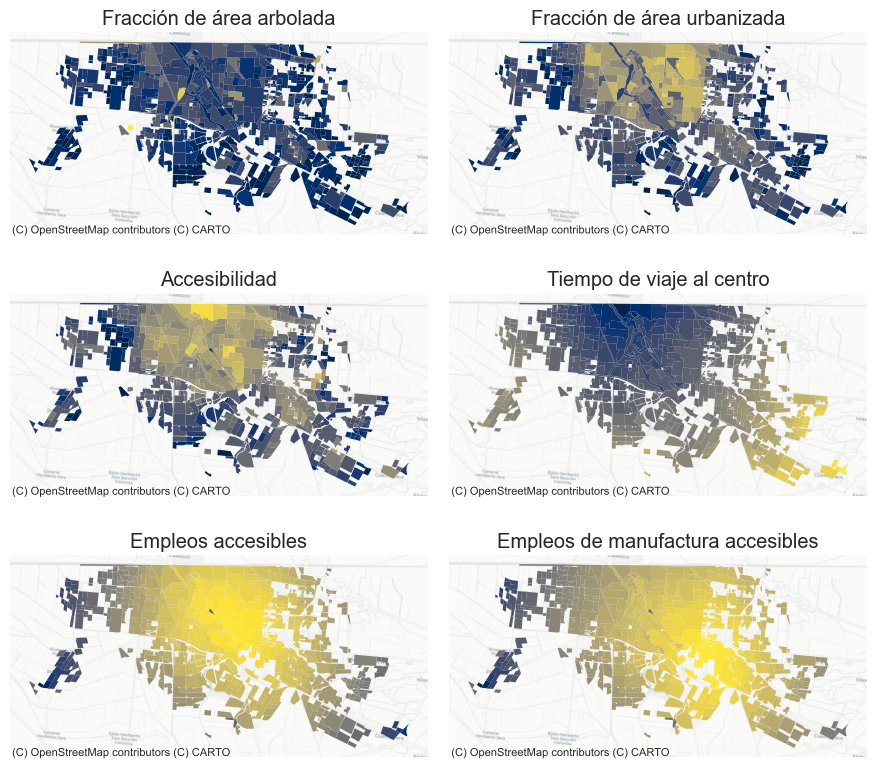

In [ ]:
name_map = {
    "tree_coverage_frac": "Fracción de área arbolada",
    "urbanized_area_frac": "Fracción de área urbanizada",
    "travel_time_to_center": "Tiempo de viaje al centro",
    "jobs": "Empleos accesibles",
    "jobs_0": "Empleos de manufactura accesibles",
    "accessibility": "Accesibilidad",
}

sns.set_theme(style="ticks", font_scale=1.2)

fig, axes = plt.subplots(3, 2, figsize=(9, 8))
for col, ax in zip(
    [
        "tree_coverage_frac",
        "urbanized_area_frac",
        "accessibility",
        "travel_time_to_center",
        "jobs",
        "jobs_0",
    ],
    axes.flatten(),
):
    df_col.plot(column=col, ax=ax, lw=0, cmap="cividis")
    ax.set_title(name_map[col])
    ax.axis("off")
    cx.add_basemap(ax, crs=df_col.crs, source=cx.providers.CartoDB.Positron, zoom=12)

fig.tight_layout()
fig.savefig(figure_path / "col_stats.jpg", bbox_inches="tight", dpi=300)

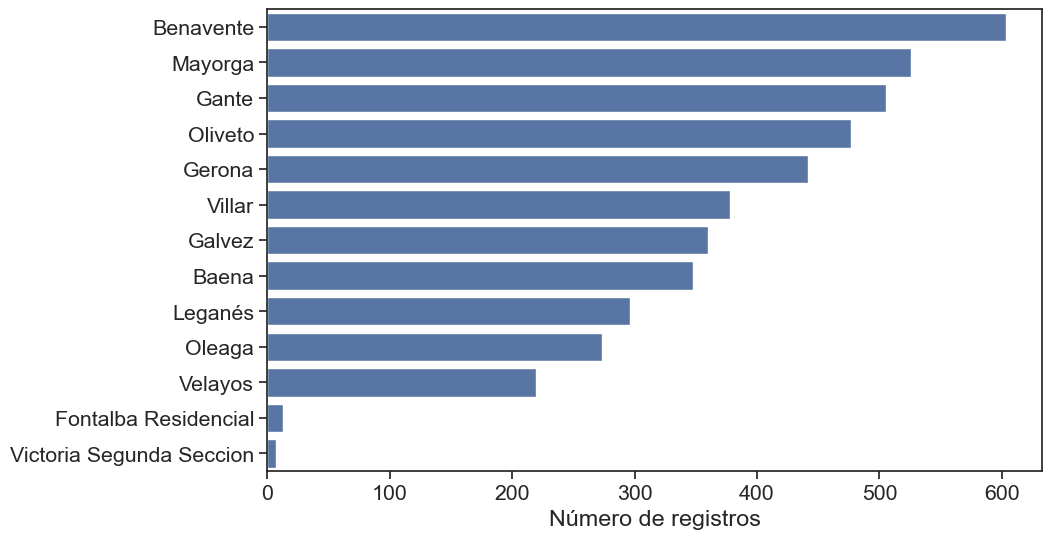

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_orig.loc[
        lambda df: df["inmobiliaria"].eq("Exe Inmobiliaria"),
        "fraccionamiento",
    ]
    .transform(
        lambda x: (
            x.str.replace("privadas condesa ", "")
            .str.replace("(", "")
            .str.replace(")", "")
            .str.title()
        ),
    )
    .value_counts(),
    ax=ax,
    orient="h",
)
ax.set_xlabel("Número de registros")
ax.set_ylabel("")
fig.savefig(figure_path / "exe_inmobiliaria.jpg", bbox_inches="tight", dpi=300)

In [ ]:
len(df_orig["fraccionamiento"].unique())

35

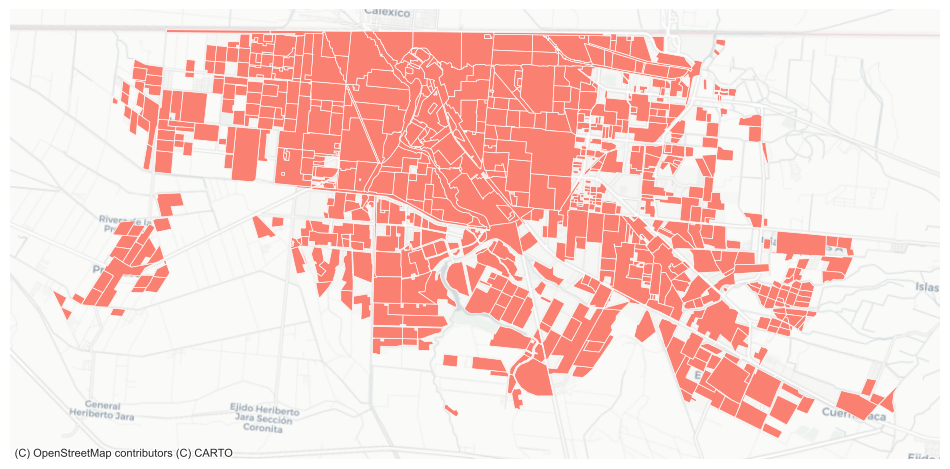

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
df_col.plot(ax=ax, fc="#FA8072", lw=0.5)
ax.axis("off")
cx.add_basemap(ax, crs=df_merge.crs, source=cx.providers.CartoDB.Positron, zoom=12)
fig.savefig(figure_path / "all_cols.jpg", bbox_inches="tight", dpi=300)

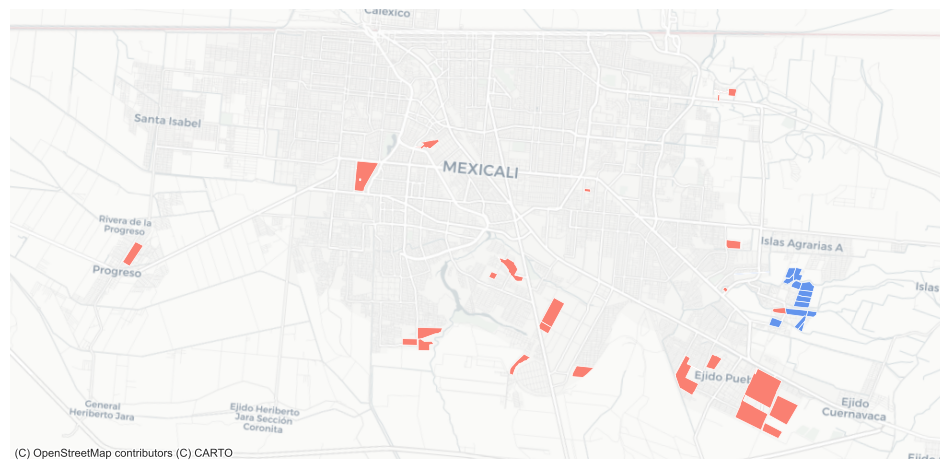

In [ ]:
xlim = ax.get_xlim()
ylim = ax.get_ylim()

temp = df_col.loc[lambda df: df.index.isin(df_orig["fraccionamiento"])]

fig, ax = plt.subplots(figsize=(12, 8))
temp.plot(
    ax=ax,
    column="is_exe",
    categorical=True,
    cmap=mcol.LinearSegmentedColormap.from_list("asd", ["#FA8072", "#6495ED"]),
    lw=0.5,
)
ax.axis("off")
cx.add_basemap(ax, crs=df_merge.crs, source=cx.providers.CartoDB.Positron, zoom=12)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

fig.savefig(figure_path / "registry_cols.jpg", bbox_inches="tight", dpi=300)

In [ ]:
df_col

,geometry,tree_coverage_frac,urbanized_area_frac,jobs,jobs_0,accessibility,travel_time_to_center,is_exe
COLONIAS,,,,,,,,
18 de marzo,"POLYGON ((1233389.196 2343271.04, 1233342.023 ...",0.056107,0.174922,241204.783967,57880.874261,0.324100,535.088783,False
27 de enero magisterial,"POLYGON ((1241329.668 2340408.209, 1241322.986...",0.004160,0.005316,171961.873828,43812.198884,0.119727,1082.647406,False
27 de septiembre,"POLYGON ((1225128.266 2345316.965, 1225110.735...",0.043113,0.340007,211810.321111,43198.625223,0.457595,263.645287,False
5 de julio,"POLYGON ((1231204.523 2340632.729, 1231181.797...",0.003377,0.054020,229047.205148,54269.749518,0.147189,535.818625,False
adara,"POLYGON ((1236092.844 2342634.529, 1236131.786...",0.000060,0.004049,227048.374252,56019.425899,0.395900,680.059325,False
...,...,...,...,...,...,...,...,...
xochimilco,"POLYGON ((1231292.147 2341852.507, 1231321.47 ...",0.029918,0.133111,236845.415217,55502.126685,0.244676,488.644784,False
zacatecas,"POLYGON ((1228960.313 2345239.214, 1228803.205...",0.047314,0.386534,242780.286421,51427.071036,0.470520,252.345085,False
zona industrial,"MULTIPOLYGON (((1230854.623 2342934.353, 12310...",0.033303,0.211268,239568.394743,51387.528938,0.427008,252.898619,False


In [ ]:
df_col.to_file("./test.gpkg")